In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip uninstall -y sklearn

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Purchased", axis=1), 
                                                    df["Purchased"], test_size=0.3, random_state=0)
X_train.shape

(280, 2)

In [5]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(X_train)


x_train_scaled = scaler.transform(X_train)
x_test_scaled = scaler.transform(X_test)

In [6]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [7]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=X_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=X_test.columns)

In [8]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


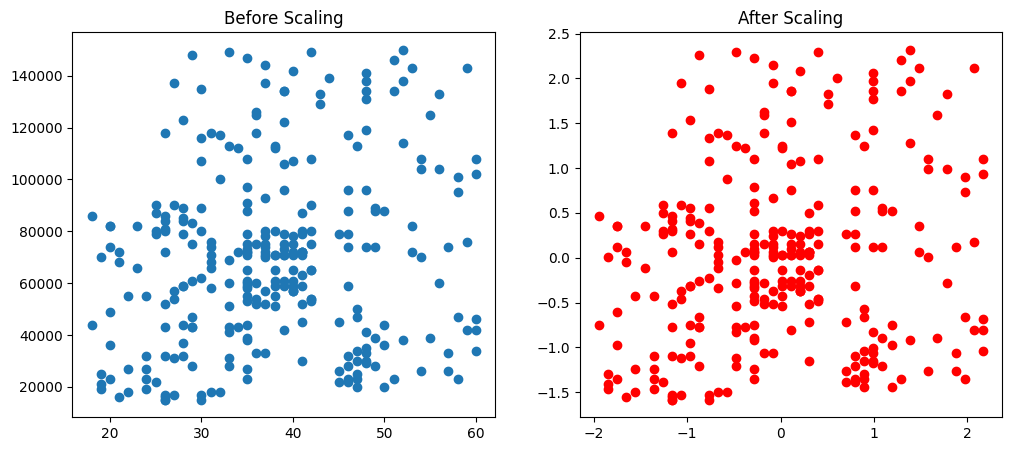

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

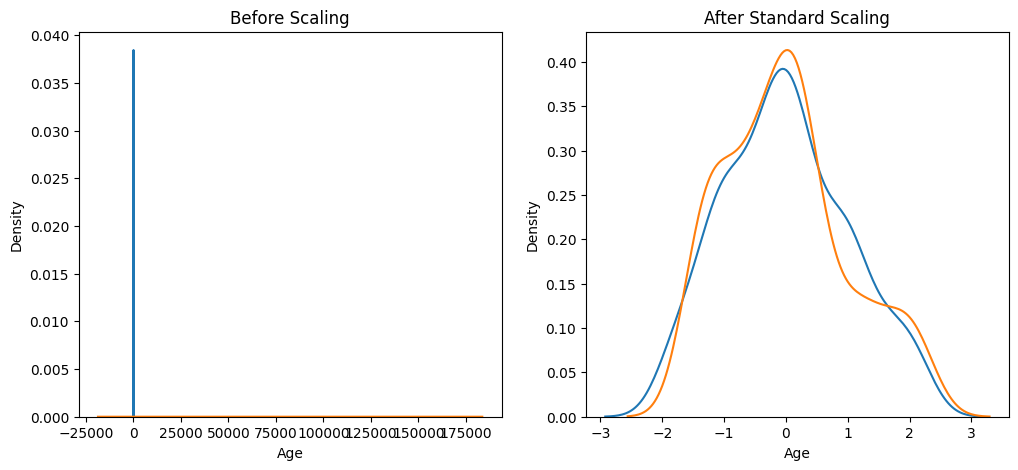

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

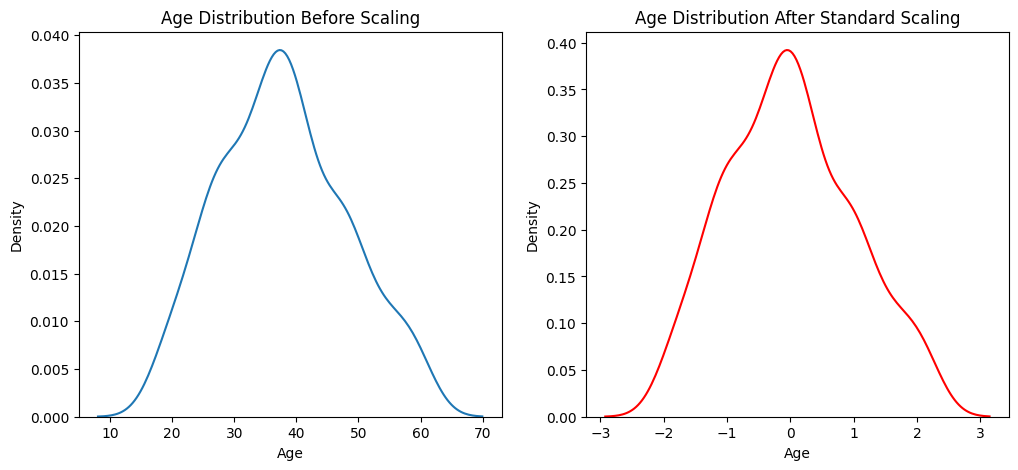

In [11]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2, color="red")
plt.show()



In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [13]:
lr.fit(X_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)

LogisticRegression()

In [14]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [15]:
from sklearn.metrics import accuracy_score

In [16]:
print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred_scaled))

0.875
0.8666666666666667


In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [18]:
dt.fit(X_train, y_train)
dt_scaled.fit(x_train_scaled, y_train)

DecisionTreeClassifier()

In [19]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt.predict(x_test_scaled)

In [20]:
print(f"UnScaled : {accuracy_score(y_test, y_pred)}")
print(f"Scaled : {accuracy_score(y_test, y_pred)}")

UnScaled : 0.875
Scaled : 0.875
